# --------------------------: Powerplant Energy Prediction :----------------------------

## 1. Load Dataset : 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

df = pd.read_csv("C:\\Users\\upadh\\Downloads\\powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


## 2. Dataset Information : 

In [2]:
print("Shape :", df.shape)

print("\nInformation\n")
df.info()

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nStatistics\n")
display(df.describe())

Shape : (9568, 5)

Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB

Missing Values

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

Statistics



,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


## 3. Correlation Heatmap : 

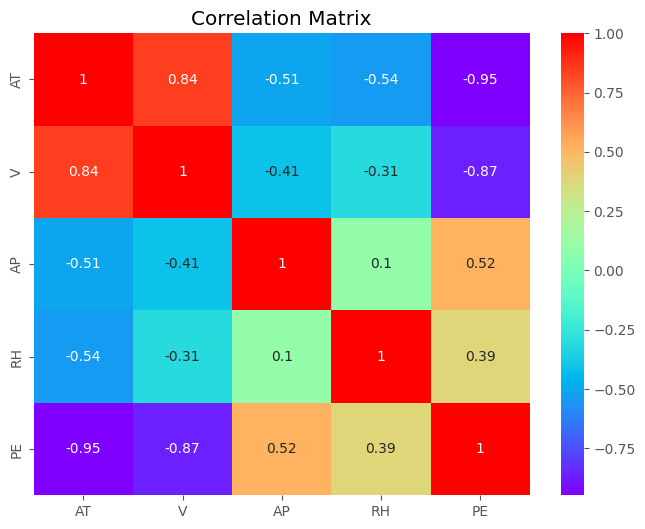

In [3]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="rainbow")
plt.title("Correlation Matrix")

plt.show()

## 4. Features & Traget : 

In [4]:
X = df.drop(columns = ["PE"])
y = df["PE"]

X

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20
...,...,...,...,...
9563,15.12,48.92,1011.80,72.93
9564,33.41,77.95,1010.30,59.72
9565,15.99,43.34,1014.20,78.66
9566,17.65,59.87,1018.58,94.65


## 5. Train Test Split : 

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(7654, 4)
(1914, 4)


## 6. Feature Scaling : 

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

## 7. 5-Fold Cross Validation : 

In [7]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 8. Linear Regression Model : 

In [8]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring="r2"
)

print("R² Score of each fold:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())

R² Score of each fold:
[0.92745876 0.92970409 0.92920131 0.92544337 0.92719309]

Average R² Score: 0.9278001240207324


## 9. Model Train : 

In [9]:
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

## 10. Evaluation Mterics : 

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 3.5434
MSE  : 19.6081
RMSE : 4.4281
R²   : 0.9315


## 11. Actual VS Predicted Plot : 

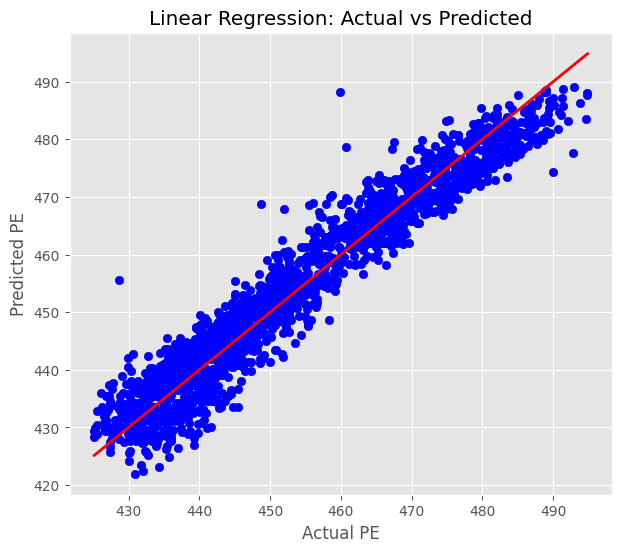

In [11]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_lr, color="blue")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

## 12. Residual Plot : 

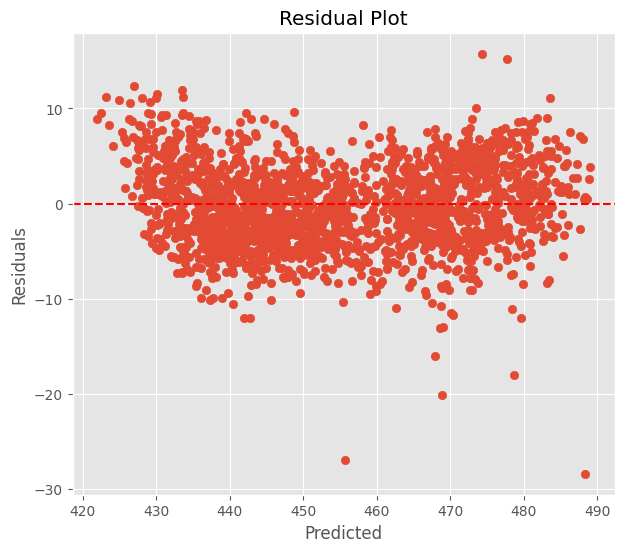

In [12]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(7,6))

plt.scatter(y_pred_lr, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## 13. Result Store : 

In [13]:
results = []

results.append([
    "Linear Regression",
    mae,
    mse,
    rmse,
    r2
])

## 14. K-Nearest Neighbors Model : 

In [14]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5, weights='uniform')

knn_cv_scores = cross_val_score(
    knn_model, 
    X_train_scaled, 
    y_train, 
    cv=kf, 
    scoring='r2'
)

print("R² Score of each fold:")
print(knn_cv_scores)

print("\nAverage R² Score:", knn_cv_scores.mean())

R² Score of each fold:
[0.94818014 0.94619311 0.94869803 0.94339196 0.94438869]

Average R² Score: 0.9461703847772791


## 15. Model Train : 

In [15]:
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

## 16. Evaluation Metrics : 

In [16]:
knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, y_pred_knn)

print(f"MAE  : {knn_mae:.4f}")
print(f"MSE  : {knn_mse:.4f}")
print(f"RMSE : {knn_rmse:.4f}")
print(f"R²   : {knn_r2:.4f}")

MAE  : 2.7067
MSE  : 13.6915
RMSE : 3.7002
R²   : 0.9522


## 17. Actual VS Predicted Plot : 

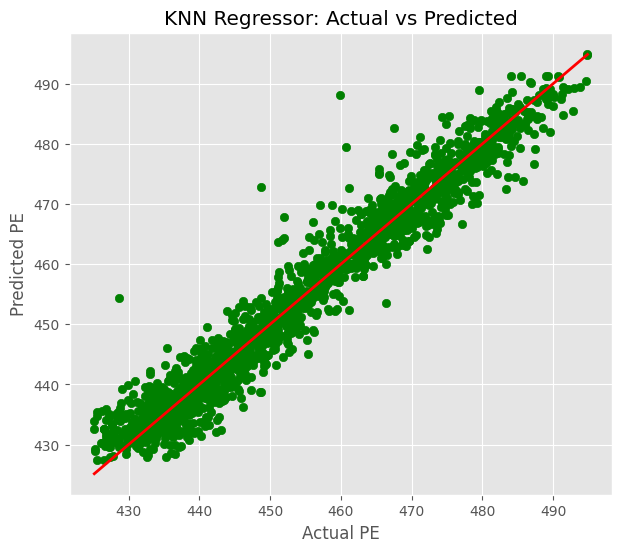

In [17]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_knn, color="green")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("KNN Regressor: Actual vs Predicted")

plt.show()

## 18. Residual Plot : 

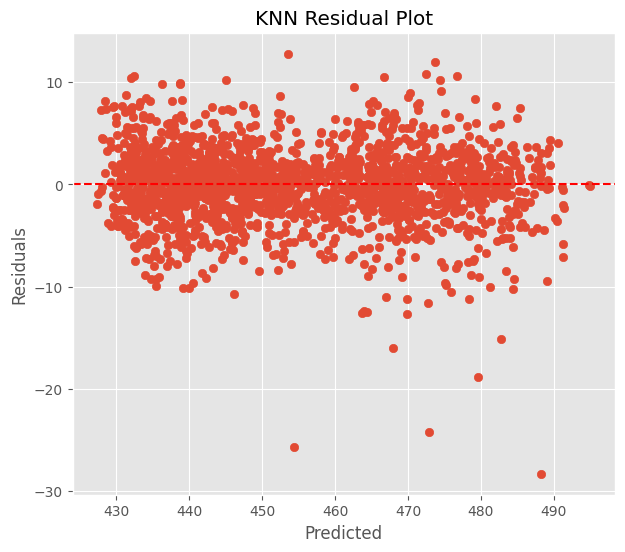

In [18]:
knn_residuals = y_test - y_pred_knn

plt.figure(figsize=(7,6))

plt.scatter(y_pred_knn, knn_residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("KNN Residual Plot")

plt.show()

## 19. Store KNN Results : 

In [19]:
results.append([
    "KNN Regressor",
    knn_mae,
    knn_mse,
    knn_rmse,
    knn_r2
])

In [20]:
results

[['Linear Regression',
  3.5434484970790163,
  19.60808532568382,
  np.float64(4.428101774539946),
  0.9314747936670361],
 ['KNN Regressor',
  2.7067304075235112,
  13.69148238871473,
  np.float64(3.7002003173767135),
  0.9521517965621104]]

## 20. Support Vector Regressor Model : 

In [21]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=100, gamma='scale',epsilon=0.1)

svr_cv_scores = cross_val_score(
    svr_model,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='r2'
)

print("R² Score of each fold:")
print(svr_cv_scores)

print("\nAverage R² Score:", svr_cv_scores.mean())

R² Score of each fold:
[0.94419421 0.94478334 0.94600109 0.94087486 0.94534586]

Average R² Score: 0.9442398701764656


## 21. Model Train : 

In [22]:
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)

## 22. Evaluation Metrics : 

In [23]:
svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, y_pred_svr)

print(f"MAE  : {svr_mae:.4f}")
print(f"MSE  : {svr_mse:.4f}")
print(f"RMSE : {svr_rmse:.4f}")
print(f"R²   : {svr_r2:.4f}")

MAE  : 2.9312
MSE  : 15.4222
RMSE : 3.9271
R²   : 0.9461


## 23. Actual VS Predicted Plot : 

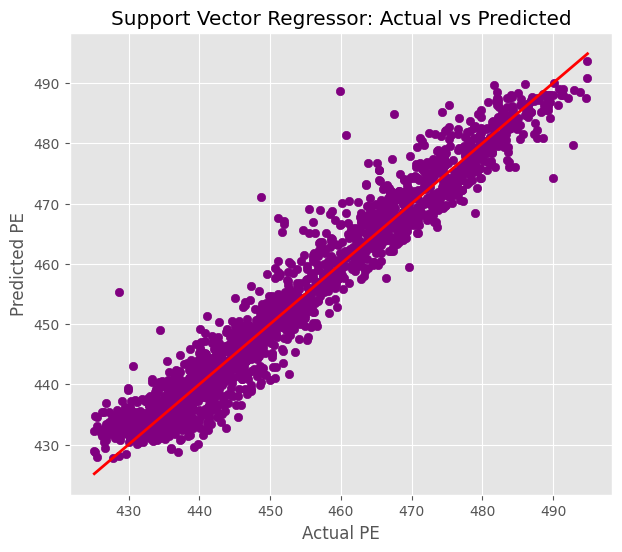

In [24]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_svr, color="purple")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("Support Vector Regressor: Actual vs Predicted")

plt.show()

## 24. Residual Plot : 

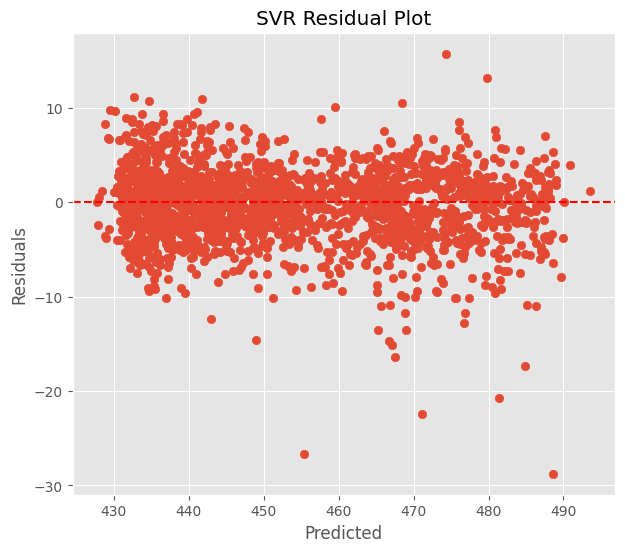

In [25]:
svr_residuals = y_test - y_pred_svr

plt.figure(figsize=(7,6))

plt.scatter(y_pred_svr, svr_residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("SVR Residual Plot")

plt.show()

## 25. Store SVR Results : 

In [26]:
results.append([
    "Support Vector Regressor",
    svr_mae,
    svr_mse,
    svr_rmse,
    svr_r2
])
results

[['Linear Regression',
  3.5434484970790163,
  19.60808532568382,
  np.float64(4.428101774539946),
  0.9314747936670361],
 ['KNN Regressor',
  2.7067304075235112,
  13.69148238871473,
  np.float64(3.7002003173767135),
  0.9521517965621104],
 ['Support Vector Regressor',
  2.93118068613081,
  15.422225172275882,
  np.float64(3.9271141022735616),
  0.9461032964468304]]

## 26. Random Forest Regressor Model :

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

print("R² Score of each fold:")
print(rf_cv_scores)

print("\nAverage R² Score:", rf_cv_scores.mean())

R² Score of each fold:
[0.96101442 0.95951701 0.95960414 0.95629516 0.95970033]

Average R² Score: 0.9592262090541276


## 27. Model Train : 

In [28]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

## 28. Evaluation Metrics : 

In [29]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"MAE  : {rf_mae:.4f}")
print(f"MSE  : {rf_mse:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

MAE  : 2.2571
MSE  : 10.1123
RMSE : 3.1800
R²   : 0.9647


## 29. Actual VS Predicted Plot : 

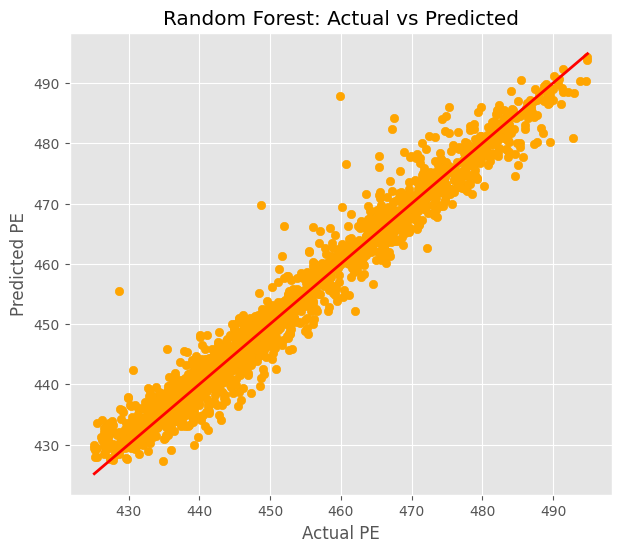

In [30]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_rf, color="orange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

## 30. Residual Plot : 

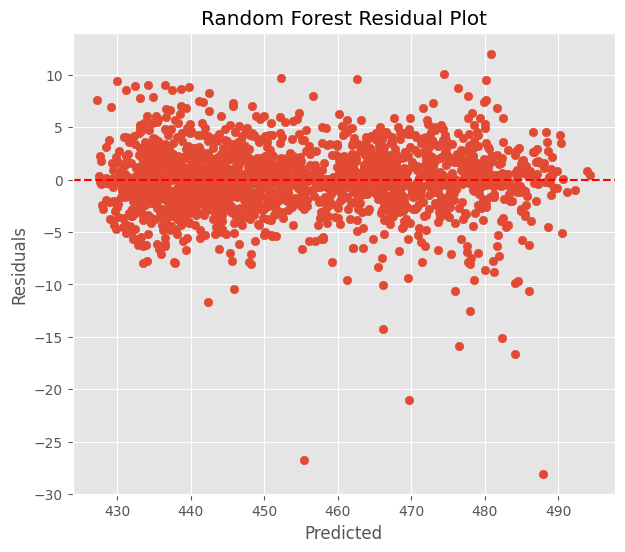

In [31]:
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(7,6))

plt.scatter(y_pred_rf, rf_residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")

plt.show()

## 31. Feature Importance : 

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,AT,0.892773
1,V,0.069822
2,AP,0.019413
3,RH,0.017992


## 32. Plot Feature Importance : 

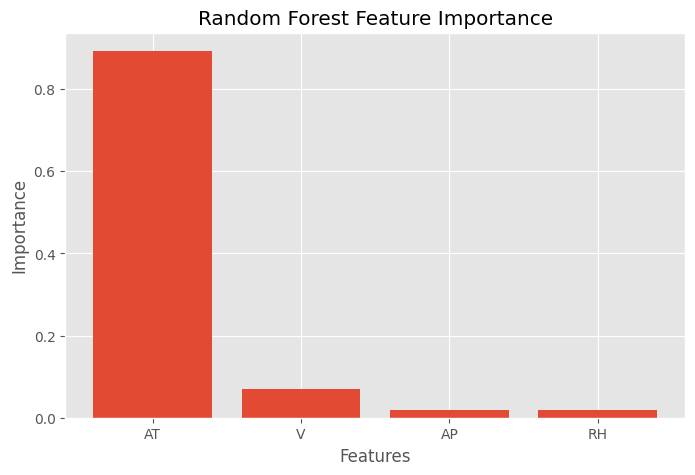

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

## 33. Store Random Forest Results : 

In [34]:
results.append([
    "Random Forest",
    rf_mae,
    rf_mse,
    rf_rmse,
    rf_r2
])
results

[['Linear Regression',
  3.5434484970790163,
  19.60808532568382,
  np.float64(4.428101774539946),
  0.9314747936670361],
 ['KNN Regressor',
  2.7067304075235112,
  13.69148238871473,
  np.float64(3.7002003173767135),
  0.9521517965621104],
 ['Support Vector Regressor',
  2.93118068613081,
  15.422225172275882,
  np.float64(3.9271141022735616),
  0.9461032964468304],
 ['Random Forest',
  2.257082157784757,
  10.112298760205135,
  np.float64(3.179984081753419),
  0.9646601211931708]]

## 34. Device Configeration : 

In [36]:
import torch 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


## 35. Convert Data to Tensor : 

In [37]:
import torch.nn as nn 

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

print(X_train_tensor)
print(y_train_tensor)

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])
tensor([[442.7500],
        [432.5200],
        [428.8000],
        ...,
        [464.2600],
        [440.4500],
        [484.4400]])


## 36. Create Dataset and DataLoader : 

In [38]:
from torch.utils.data import Dataset, DataLoader 

class PowerPlantDataset(Dataset) :
    def __init__(self, X, y) :
        self.X = X
        self.y = y

    def __len__(self) :
        return len(self.X)

    def __getitem__(self, idx) :
        return self.X[idx], self.y[idx]


train_dataset = PowerPlantDataset(X_train_tensor, y_train_tensor)
test_dataset = PowerPlantDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(train_loader)
print(test_loader)

## 37. Feed Forward Neural Network Model : 

In [39]:
class FNN(nn.Module) :
    def __init__(self) :
        super(FNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,1)
        )

    def forward(self, x) :
        return self.network(x)


import torch.optim as optim

model = FNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

FNN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 38. Training Loop :

In [40]:
num_epochs = 100

train_losses = []
test_losses = []

for epoch in range(num_epochs) :
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader :
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)


    model.eval()
    running_test_loss = 0.0

    with torch.no_grad() :
        for X_batch, y_batch in test_loader :
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item() * X_batch.size(0)

    epoch_test_loss = running_test_loss / len(test_loader.dataset)

    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)

    if (epoch + 1) % 10 == 0 :
        print(f"Epoch [{epoch+1}/{num_epochs}] " f"Train Loss: {epoch_train_loss:.4f} " f"Test Loss: {epoch_test_loss:.4f}")

Epoch [10/100] Train Loss: 36.0266 Test Loss: 31.7514
Epoch [20/100] Train Loss: 21.1339 Test Loss: 20.3215
Epoch [30/100] Train Loss: 20.1168 Test Loss: 18.9820
Epoch [40/100] Train Loss: 19.7460 Test Loss: 17.8572
Epoch [50/100] Train Loss: 19.1238 Test Loss: 20.1783
Epoch [60/100] Train Loss: 19.9461 Test Loss: 18.0876
Epoch [70/100] Train Loss: 19.1399 Test Loss: 16.5484
Epoch [80/100] Train Loss: 18.1566 Test Loss: 17.7765
Epoch [90/100] Train Loss: 18.7480 Test Loss: 17.1641
Epoch [100/100] Train Loss: 18.0558 Test Loss: 16.5845


## 39. Predict On Test Data : 

In [41]:
model.eval()

with torch.no_grad() :
    y_pred_fnn = model(X_test_tensor.to(device))
    y_pred_fnn = y_pred_fnn.cpu().numpy()

## 40. Evaluation Metrics : 

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

fnn_mae = mean_absolute_error(y_test, y_pred_fnn)
fnn_mse = mean_squared_error(y_test, y_pred_fnn)
fnn_rmse = np.sqrt(fnn_mse)
fnn_r2 = r2_score(y_test, y_pred_fnn)

print(f"MAE  : {fnn_mae:.4f}")
print(f"MSE  : {fnn_mse:.4f}")
print(f"RMSE : {fnn_rmse:.4f}")
print(f"R²   : {fnn_r2:.4f}")

MAE  : 3.1823
MSE  : 16.5845
RMSE : 4.0724
R²   : 0.9420


## 41. Training VS Validation Loss Curve : 

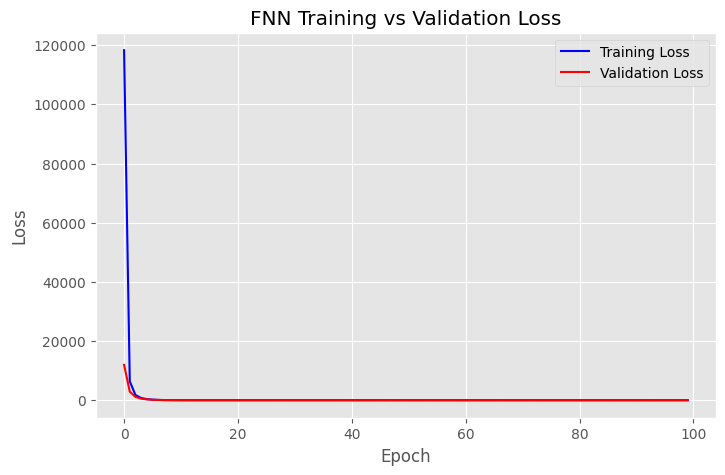

In [45]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label = "Training Loss", color = "blue")
plt.plot(test_losses, label = "Validation Loss", color = "red")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FNN Training vs Validation Loss")

plt.legend()
plt.show()

## 42. Actual VS Predicted Plot : 

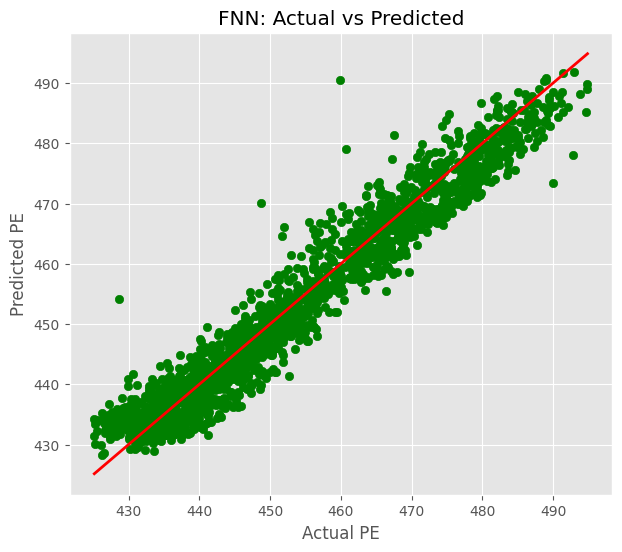

In [46]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_fnn, color="green")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("FNN: Actual vs Predicted")

plt.show()

## 43. Residual Plot : 

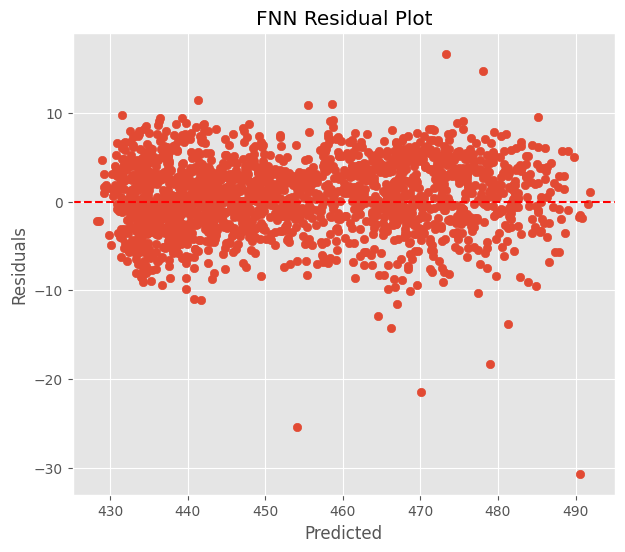

In [47]:
residuals = y_test.values.reshape(-1,1) - y_pred_fnn

plt.figure(figsize=(7,6))

plt.scatter(y_pred_fnn, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("FNN Residual Plot")

plt.show()

## 44. Store FNN Results :

In [48]:
results.append([
    "Feed Forward Neural Network",
    fnn_mae,
    fnn_mse,
    fnn_rmse,
    fnn_r2
])

results

[['Linear Regression',
  3.5434484970790163,
  19.60808532568382,
  np.float64(4.428101774539946),
  0.9314747936670361],
 ['KNN Regressor',
  2.7067304075235112,
  13.69148238871473,
  np.float64(3.7002003173767135),
  0.9521517965621104],
 ['Support Vector Regressor',
  2.93118068613081,
  15.422225172275882,
  np.float64(3.9271141022735616),
  0.9461032964468304],
 ['Random Forest',
  2.257082157784757,
  10.112298760205135,
  np.float64(3.179984081753419),
  0.9646601211931708],
 ['Feed Forward Neural Network',
  3.182273384819708,
  16.5844806368874,
  np.float64(4.072404773212923),
  0.9420415130446643]]

## 45. Create Result Dataframe : 

In [75]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,3.543448,19.608085,4.428102,0.931475
1,KNN Regressor,2.706730,13.691482,3.700200,0.952152
2,Support Vector Regressor,2.931181,15.422225,3.927114,0.946103
3,Random Forest,2.257082,10.112299,3.179984,0.964660
4,Feed Forward Neural Network,3.182273,16.584481,4.072405,0.942042


## 46. Sort By R2-Score : 

In [76]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest,2.257082,10.112299,3.179984,0.964660
1,KNN Regressor,2.706730,13.691482,3.700200,0.952152
2,Support Vector Regressor,2.931181,15.422225,3.927114,0.946103
3,Feed Forward Neural Network,3.182273,16.584481,4.072405,0.942042
4,Linear Regression,3.543448,19.608085,4.428102,0.931475


## 47. Best Model : 

In [77]:
best_model = results_df.iloc[0]

print("Best Model")
print("-------------------------")
print(f"Model      : {best_model['Model']}")
print(f"MAE        : {best_model['MAE']:.4f}")
print(f"MSE        : {best_model['MSE']:.4f}")
print(f"RMSE       : {best_model['RMSE']:.4f}")
print(f"R² Score   : {best_model['R2 Score']:.4f}")

Best Model
-------------------------
Model      : Random Forest
MAE        : 2.2571
MSE        : 10.1123
RMSE       : 3.1800
R² Score   : 0.9647


## 48. Compare R2-Score : 

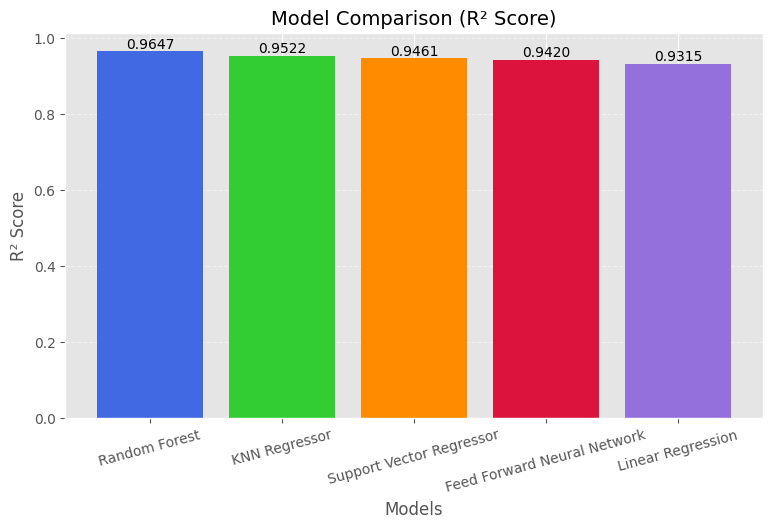

In [78]:
colors = ["royalblue", "limegreen", "darkorange", "crimson", "mediumpurple"    ]

plt.figure(figsize=(9,5))

bars = plt.bar(results_df["Model"], results_df["R2 Score"], color=colors)

plt.title("Model Comparison (R² Score)", fontsize = 14)
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation = 15)

for bar in bars :
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha = 'center',
        va = 'bottom'
    )

plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

## 49. Compare RMSE : 

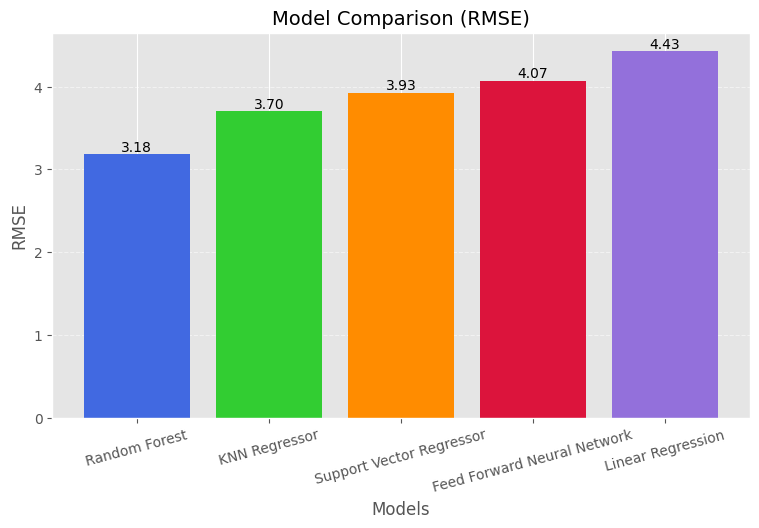

In [79]:
plt.figure(figsize=(9,5))

bars = plt.bar(results_df["Model"], results_df["RMSE"], color = colors)

plt.title("Model Comparison (RMSE)", fontsize = 14)
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation = 15)

for bar in bars :
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha = 'center',
        va = 'bottom'
    )

plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

## 50. Compare MSE : 

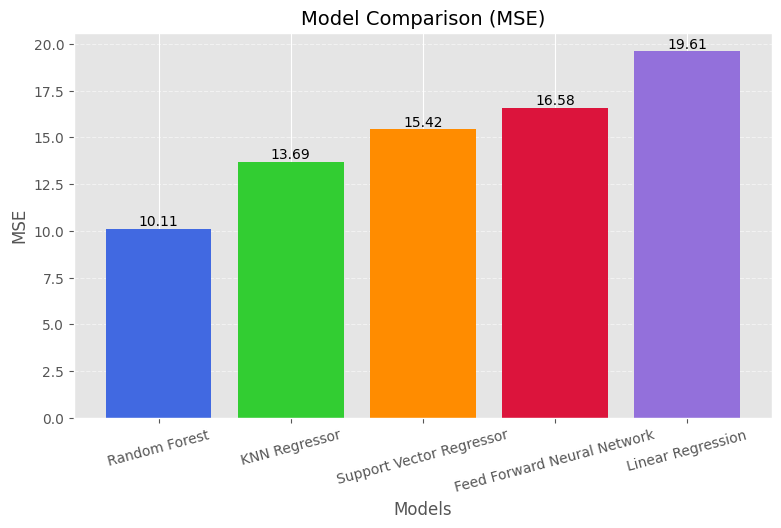

In [80]:
plt.figure(figsize=(9,5))

bars = plt.bar(results_df["Model"], results_df["MSE"], color = colors)

plt.title("Model Comparison (MSE)", fontsize = 14)
plt.xlabel("Models")
plt.ylabel("MSE")

plt.xticks(rotation = 15)

for bar in bars :
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha = 'center',
        va = 'bottom'
    )

plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

## 51. Compare MAE : 

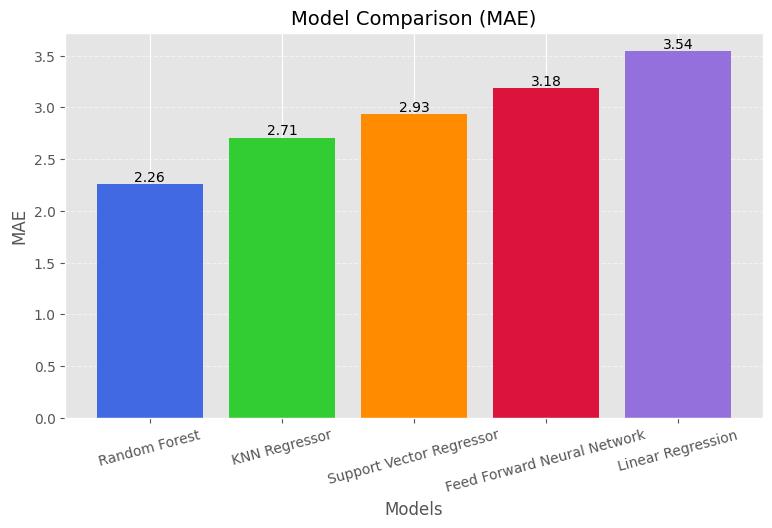

In [81]:
plt.figure(figsize=(9,5))

bars = plt.bar(results_df["Model"], results_df["MAE"], color = colors)

plt.title("Model Comparison (MAE)", fontsize=14)
plt.xlabel("Models")
plt.ylabel("MAE")

plt.xticks(rotation = 15)

for bar in bars :
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha = 'center',
        va = 'bottom'
    )

plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

## 52. Final Model Comparison Summary : 

In [82]:
print("=" * 85)
print("{:<30} {:<10} {:<10} {:<10} {:<10}".format(
    "Model", "MAE", "MSE", "RMSE", "R²"))
print("=" * 85)

for _, row in results_df.iterrows() :
    print("{:<30} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        row["Model"],
        row["MAE"],
        row["MSE"],
        row["RMSE"],
        row["R2 Score"]
    ))

print("=" * 85)

Model                          MAE        MSE        RMSE       R²        
Random Forest                  2.2571     10.1123    3.1800     0.9647    
KNN Regressor                  2.7067     13.6915    3.7002     0.9522    
Support Vector Regressor       2.9312     15.4222    3.9271     0.9461    
Feed Forward Neural Network    3.1823     16.5845    4.0724     0.9420    
Linear Regression              3.5434     19.6081    4.4281     0.9315    


## 53. Results DataFrame : 

In [83]:
results_df.insert(
    0, "Rank", ["🥇","🥈","🥉","🏅","🏅"]
)

results_df.style\
    .hide(axis="index")\
    .background_gradient(cmap="Greens", subset=["R2 Score"])\
    .background_gradient(cmap="Blues_r", subset=["MAE"])\
    .background_gradient(cmap="Oranges_r", subset=["MSE"])\
    .background_gradient(cmap="Purples_r", subset=["RMSE"])\
    .format(precision=4)\
    .set_caption("Final Model Leaderboard")

Rank,Model,MAE,MSE,RMSE,R2 Score
🥇,Random Forest,2.2571,10.1123,3.1800,0.9647
🥈,KNN Regressor,2.7067,13.6915,3.7002,0.9522
🥉,Support Vector Regressor,2.9312,15.4222,3.9271,0.9461
🏅,Feed Forward Neural Network,3.1823,16.5845,4.0724,0.9420
🏅,Linear Regression,3.5434,19.6081,4.4281,0.9315
